In [4]:
# Import librării
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV, KFold


In [6]:
df = pd.read_csv('house_4.csv')
df.head()
    

,Unnamed: 0,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,1,42000.0,5850,3,1,2,yes,no,yes,no,no,1,no
1,2,38500.0,4000,2,1,1,yes,no,no,no,no,0,no
2,3,49500.0,3060,3,1,1,yes,no,no,no,no,0,no
3,4,60500.0,6650,3,1,2,yes,yes,no,no,no,0,no
4,5,61000.0,6360,2,1,1,yes,no,no,no,no,0,no


In [8]:
df.shape

(546, 13)

In [9]:
df.isna().sum()

Unnamed: 0    0
price         0
lotsize       0
bedrooms      0
bathrms       0
stories       0
driveway      0
recroom       0
fullbase      0
gashw         0
airco         0
garagepl      0
prefarea      0
dtype: int64

In [13]:
print("===== Tipurile de date =====")
df.dtypes

===== Tipurile de date =====


Unnamed: 0      int64
price         float64
lotsize         int64
bedrooms        int64
bathrms         int64
stories         int64
driveway       object
recroom        object
fullbase       object
gashw          object
airco          object
garagepl        int64
prefarea       object
dtype: object

In [12]:
df=df.dropna()

In [ ]:
#setul de date are 546 de linii si 13 coloane
#nu exista valori lipsa
#am elemente int si object

In [14]:
# Informații despre coloane, tipuri de date și valori lipsă
print("===== Rezumat DataFrame =====")
df.info()

===== Rezumat DataFrame =====
,<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 546 entries, 0 to 545
,Data columns (total 13 columns):
, #   Column      Non-Null Count  Dtype  
,---  ------      --------------  -----  
, 0   Unnamed: 0  546 non-null    int64  
, 1   price       546 non-null    float64
, 2   lotsize     546 non-null    int64  
, 3   bedrooms    546 non-null    int64  
, 4   bathrms     546 non-null    int64  
, 5   stories     546 non-null    int64  
, 6   driveway    546 non-null    object 
, 7   recroom     546 non-null    object 
, 8   fullbase    546 non-null    object 
, 9   gashw       546 non-null    object 
, 10  airco       546 non-null    object 
, 11  garagepl    546 non-null    int64  
, 12  prefarea    546 non-null    object 
,dtypes: float64(1), int64(6), object(6)
,memory usage: 55.6+ KB


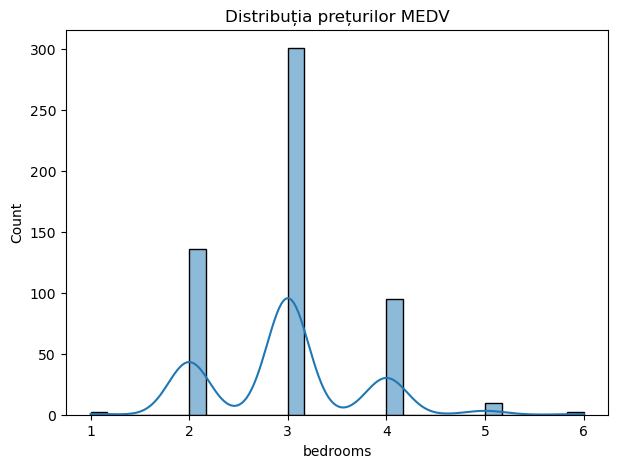

In [16]:
# Distribuția variabilei țintă (MEDV - prețul median al locuințelor)
# Setearea dimensiunii figurii pentru grafic
plt.figure(figsize=(7,5))  

# Crearea unei histograme cu curba de densitate (KDE) pentru variabila țintă MEDV
sns.histplot(df['bedrooms'], kde=True, bins=30)  

# Adăugarea titlului pentru grafic
plt.title('Distribuția prețurilor MEDV')  

# Afișare grafic
plt.show()  


In [ ]:
#Variabila bedrooms este discretă (numerică întreagă).

#Distribuția este asimetrică spre dreapta (puține locuințe cu multe dormitoare).

#Cea mai frecventă categorie este 3 dormitoare, reprezentând tipul cel mai comun de locuință din eșantion

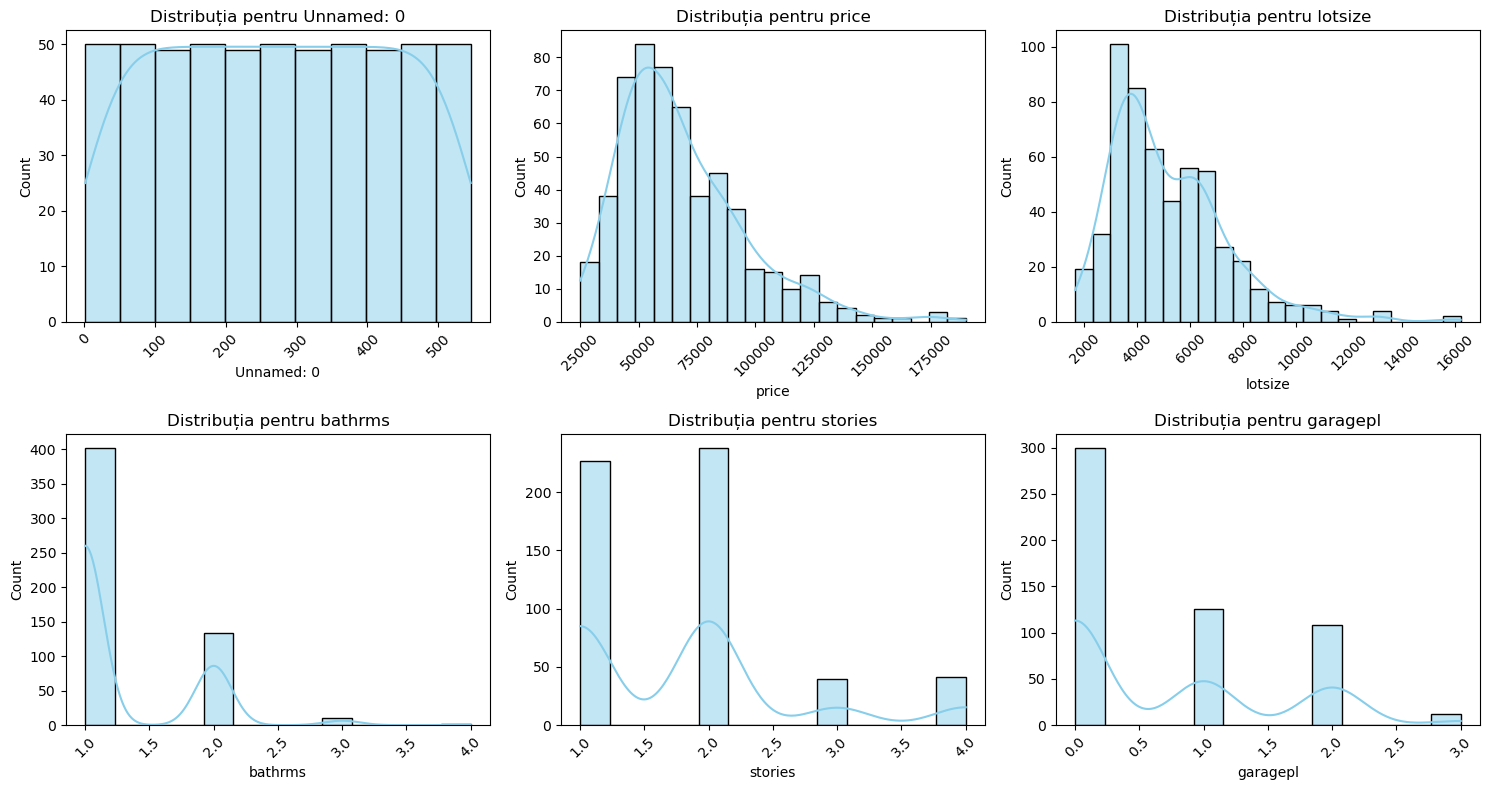

In [19]:
# Distribuția tuturor variabilelor

# Selectarea coloanelor numerice
df_plot=df.drop('bedrooms', axis=1)
num_cols = df_plot.select_dtypes(include=[np.number]).columns

# Setare subgraficului
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten()

# Creare distplot pentru fiecare coloană numerică
for i, col in enumerate(num_cols):
    sns.histplot(df_plot[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f"Distribuția pentru {col}")
    axes[i].tick_params(axis='x', rotation=45)

# Ascunderea subploturilor goale
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:

#price (prețul locuinței - variabila țintă)
#Distribuție aproximativ normală, ușor asimetrică spre dreapta.
#Majoritatea locuințelor au prețuri în zona medie, foarte puține sunt extrem de scumpe.

#lotsize (mărimea terenului)
#Distribuție foarte asimetrică spre dreapta.
#Majoritatea terenurilor sunt mici/medii, cu câteva valori foarte mari 

#bathrms (numărul de băi)
#Variabilă discretă, valorile mici sunt cele mai frecvente (1–2 băi).
#Puține locuințe au mai mult de 2 băi.

#stories (numărul de etaje)
#Variabilă discretă. Cele mai multe case au 1 sau 2 etaje.
#Valori de 3–4 etaje sunt rare.

#garagepl (numărul de locuri în garaj)
#Majoritatea locuințelor au fie 0, fie 1 loc de garaj.
#Locuințele cu garaj mare (2–3 locuri) sunt puține

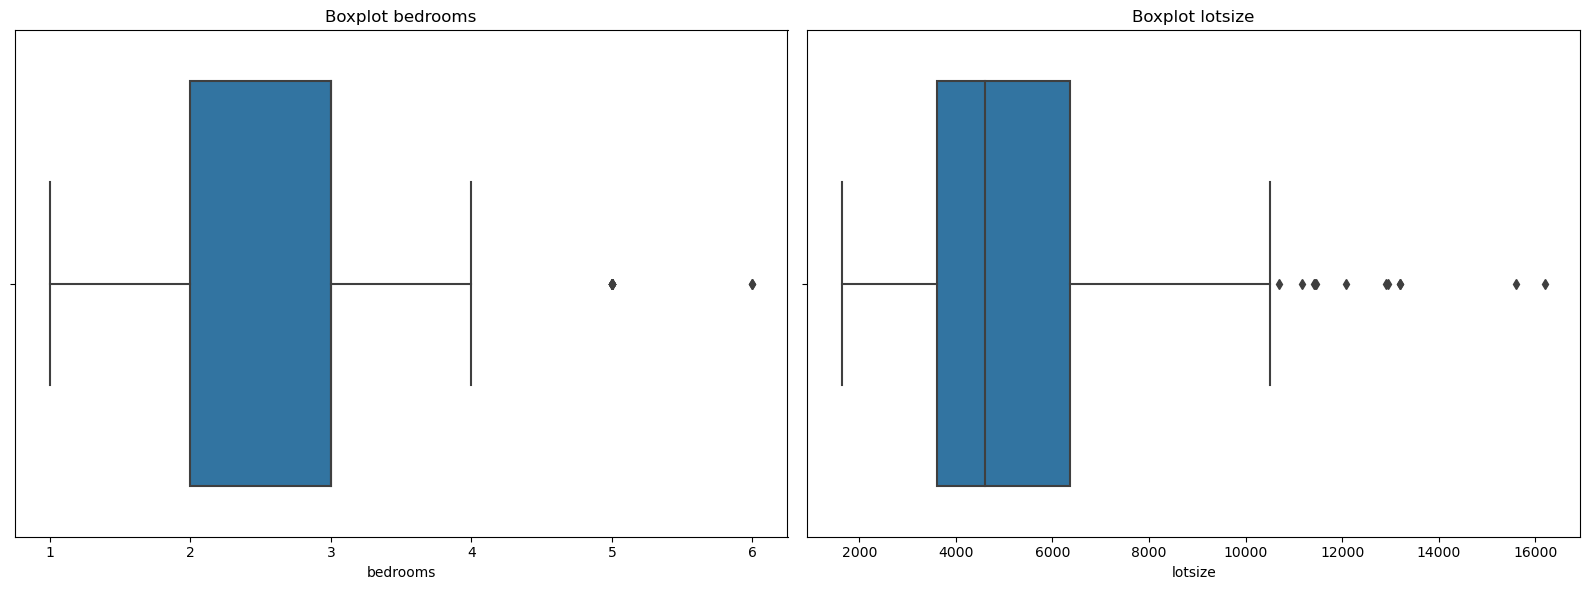

In [24]:
# Creare figură cu 1 rând și 2 coloane
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot pentru MEDV
sns.boxplot(x=df['bedrooms'], ax=axes[0])
axes[0].set_title("Boxplot bedrooms")

# Boxplot pentru RM
sns.boxplot(x=df['lotsize'], ax=axes[1])
axes[1].set_title("Boxplot lotsize")

plt.tight_layout()
plt.show()


In [26]:
# Codificare binară pentru variabilele categoriale
binary_cols = ['driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'prefarea']

# Înlocuim "yes" cu 1 și "no" cu 0
df[binary_cols] = df[binary_cols].replace({'yes': 1, 'no': 0})

In [27]:
df[binary_cols].head()

,driveway,recroom,fullbase,gashw,airco,prefarea
0,1,0,1,0,0,0
1,1,0,0,0,0,0
2,1,0,0,0,0,0
3,1,1,0,0,0,0
4,1,0,0,0,0,0


In [28]:
# Informații despre coloane, tipuri de date și valori lipsă
print("===== Rezumat DataFrame =====")
df.info()

===== Rezumat DataFrame =====
,<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 546 entries, 0 to 545
,Data columns (total 13 columns):
, #   Column      Non-Null Count  Dtype  
,---  ------      --------------  -----  
, 0   Unnamed: 0  546 non-null    int64  
, 1   price       546 non-null    float64
, 2   lotsize     546 non-null    int64  
, 3   bedrooms    546 non-null    int64  
, 4   bathrms     546 non-null    int64  
, 5   stories     546 non-null    int64  
, 6   driveway    546 non-null    int64  
, 7   recroom     546 non-null    int64  
, 8   fullbase    546 non-null    int64  
, 9   gashw       546 non-null    int64  
, 10  airco       546 non-null    int64  
, 11  garagepl    546 non-null    int64  
, 12  prefarea    546 non-null    int64  
,dtypes: float64(1), int64(12)
,memory usage: 55.6 KB


In [ ]:
#nu am elemente lipsa sau dubluri
#am codificat elementele categoriale

In [29]:
df.duplicated().sum()

0

In [ ]:
#nu exista dubluri de sters

In [30]:
# Variabila țintă
y = df['price']
print("=== Variabila țintă ===")
print(y.head())

=== Variabila țintă ===
,0    42000.0
,1    38500.0
,2    49500.0
,3    60500.0
,4    61000.0
,Name: price, dtype: float64


In [31]:
# Variabilele independente
X = df.drop('price', axis=1)
print("=== Variabilele independente ===")
X.head()

=== Variabilele independente ===


,Unnamed: 0,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,1,5850,3,1,2,1,0,1,0,0,1,0
1,2,4000,2,1,1,1,0,0,0,0,0,0
2,3,3060,3,1,1,1,0,0,0,0,0,0
3,4,6650,3,1,2,1,1,0,0,0,0,0
4,5,6360,2,1,1,1,0,0,0,0,0,0


In [32]:
print("Dimensiuni X, y:", X.shape, y.shape)

Dimensiuni X, y: (546, 12) (546,)


In [33]:
df = df.copy()
df.head()

,Unnamed: 0,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,1,42000.0,5850,3,1,2,1,0,1,0,0,1,0
1,2,38500.0,4000,2,1,1,1,0,0,0,0,0,0
2,3,49500.0,3060,3,1,1,1,0,0,0,0,0,0
3,4,60500.0,6650,3,1,2,1,1,0,0,0,0,0
4,5,61000.0,6360,2,1,1,1,0,0,0,0,0,0


In [1]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')


<class 'NameError'>: name 'df' is not defined

In [ ]:
#am sters datele din Unnamed: 0 deoarece datele din aceasta coloana sunt irelevante

In [44]:
df.head()

,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,42000.0,5850,3,1,2,1,0,1,0,0,1,0
1,38500.0,4000,2,1,1,1,0,0,0,0,0,0
2,49500.0,3060,3,1,1,1,0,0,0,0,0,0
3,60500.0,6650,3,1,2,1,1,0,0,0,0,0
4,61000.0,6360,2,1,1,1,0,0,0,0,0,0


In [45]:
print("Cele mai corelate variabile cu price:")
print(df.corr()['price'].sort_values(ascending=False).head(10))

Cele mai corelate variabile cu price:
,price       1.000000
,lotsize     0.535796
,bathrms     0.516719
,airco       0.453347
,stories     0.421190
,garagepl    0.383302
,bedrooms    0.366447
,prefarea    0.329074
,driveway    0.297167
,recroom     0.254960
,Name: price, dtype: float64


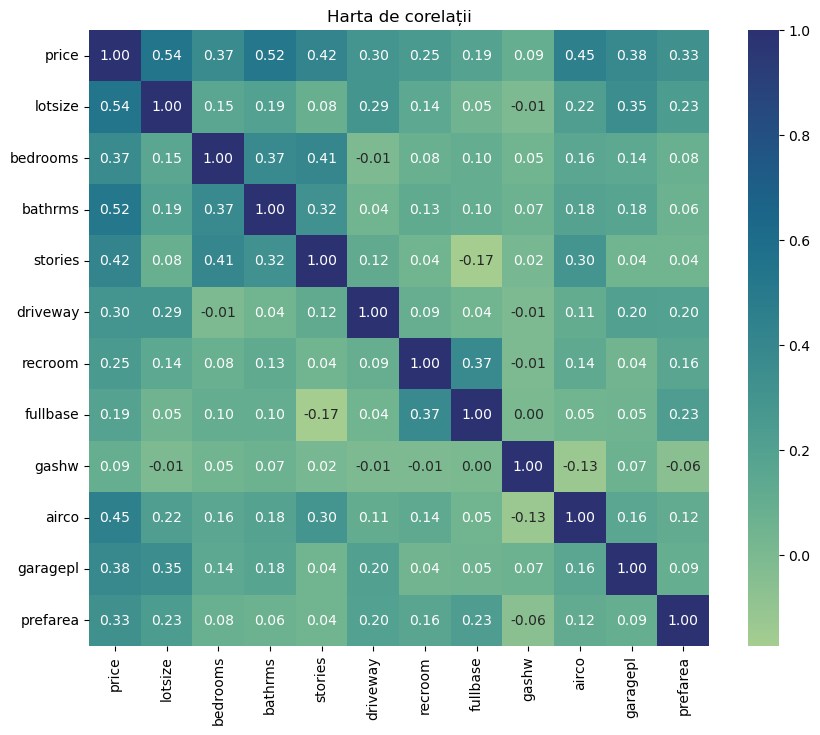

In [46]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap="crest")
plt.title('Harta de corelații')
plt.show()



In [47]:
#price are corelație 0.54 cu lotsize moderată, dar nu ridicată

#bedrooms bathrms 0.37 mică spre moderată.

#recroom – fullbase 0.37  mică spre moderată.

#airco price 0.45 → moderată.

#nu exista coloane cu corelabilitate mare 

In [48]:
# Variabila țintă
y = df['price']
print("=== Variabila țintă ===")
print(y.head())

=== Variabila țintă ===
,0    42000.0
,1    38500.0
,2    49500.0
,3    60500.0
,4    61000.0
,Name: price, dtype: float64


In [49]:
# Variabilele independente
X = df.drop('price', axis=1)
print("=== Variabilele independente ===")
X.head()

=== Variabilele independente ===


,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,5850,3,1,2,1,0,1,0,0,1,0
1,4000,2,1,1,1,0,0,0,0,0,0
2,3060,3,1,1,1,0,0,0,0,0,0
3,6650,3,1,2,1,1,0,0,0,0,0
4,6360,2,1,1,1,0,0,0,0,0,0


In [41]:
print("Dimensiuni X, y:", X.shape, y.shape)

Dimensiuni X, y: (546, 11) (546,)


In [51]:
# Creare date de antrenare și de testare
from sklearn.model_selection import train_test_split

# Împărțirea datelor în set de antrenare și testare
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Dimensiune set antrenare:", X_train.shape, y_train.shape)
print("Dimensiune set test:", X_test.shape, y_test.shape)

Dimensiune set antrenare: (436, 11) (436,)
,Dimensiune set test: (110, 11) (110,)


In [52]:
from sklearn.linear_model import LinearRegression

# Crearea modelului
housing_model1 = LinearRegression()
# Antrenarea modelului pe datele de antrenare
housing_model1.fit(X_train, y_train)

LinearRegression()

In [53]:
print("Coeficienți:", housing_model1.coef_) #coeficientul pentru variabila RM.
print("Intercept:", housing_model1.intercept_) #termenul liber din ecuația de regresie.

Coeficienți: [3.65398978e+00 9.55865044e+02 1.35822404e+04 7.20464908e+03
, 6.94001236e+03 4.55674435e+03 6.37702327e+03 1.51289605e+04
, 1.26746163e+04 4.61164795e+03 7.81519389e+03]
,Intercept: -2513.002578839092


In [55]:
# Prezicerea valorilor pentru setul de test
price_pred1 = housing_model1.predict(X_test)
r2_1 = housing_model1.score(X_test, y_test)
print('R-square: %.4f' % r2_1 )

R-square: 0.6160


In [63]:
# Evaluarea performanței modelului

MSE3 = mean_squared_error( y_test, price_pred1)
print("MSE:", MSE3)

RMSE3 = np.sqrt(MSE3)
print("RMSE:", RMSE3)


MSE: 256524986.51986215
,RMSE: 16016.397426383443


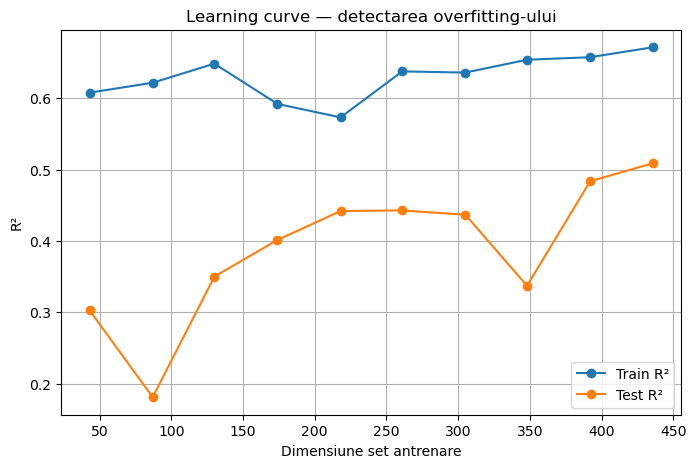

In [64]:
from sklearn.pipeline import make_pipeline

# Copiem datele și împărțim în set train/test
X_m = X.copy()      # copiați caracteristicile
y_m = y             # ținta
X_train, X_test, y_train, y_test = train_test_split(
    X_m, y_m, test_size=0.2, random_state=42
)  # 80% train, 20% test


pipeline = make_pipeline(StandardScaler(), LinearRegression())


# --- Generarea Curbei de Învățare cu Pipeline-ul ---
train_sizes, train_scores, test_scores = learning_curve(
    pipeline, # Utilizăm Pipeline-ul
    X_m, y_m, 
    cv=5, 
    scoring='r2',  
    train_sizes=np.linspace(0.1, 1.0, 10),)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, 'o-', label='Train R²')
plt.plot(train_sizes, test_mean, 'o-', label='Test R²')
plt.title('Learning curve — detectarea overfitting-ului')
plt.xlabel('Dimensiune set antrenare')
plt.ylabel('R²')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Performanță mare pe Train
#Modelul învață bine pe datele de antrenare R² relativ ridicat

#Performanță slabă pe Test
#R² pe test este semnificativ mai mic, oscilează puternic și nu urmează linia de train. Asta arată că modelul nu generalizează bine pe date noi.

#Diferență mare Train vs. Test
#Overfitting  modelul memorează prea mult setul de train și nu poate generaliza
#modelul se duce in underfitting

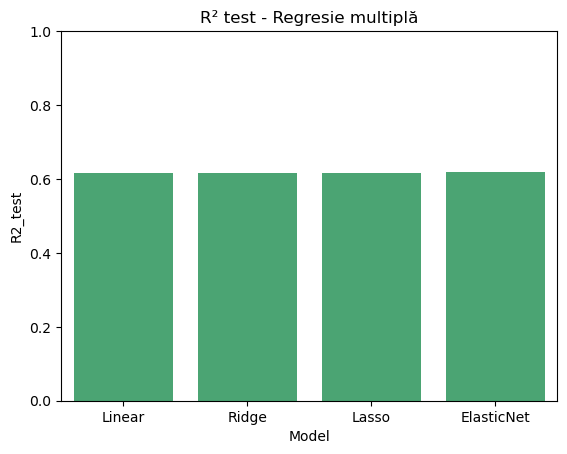

,Model,R2_test,MSE_test
0,Linear,0.616024,2.565250e+08
1,Ridge,0.616203,2.564057e+08
2,Lasso,0.616025,2.565244e+08
3,ElasticNet,0.619003,2.545347e+08


In [65]:
#  Regularizare Ridge, Lasso, ElasticNet

# Standardizare date
scaler = StandardScaler()  
X_train_s = scaler.fit_transform(X_train)  # calculăm media și deviația standard pe train și transformăm
X_test_s = scaler.transform(X_test)        # transformăm test folosind media și std din train


# Antrenăm modelele
lin_multi = LinearRegression().fit(X_train_s, y_train)             # regresie liniară simplă
ridge_multi = Ridge(alpha=1.0).fit(X_train_s, y_train)            # Ridge cu alpha=1.0
lasso_multi = Lasso(alpha=0.1, max_iter=10000).fit(X_train_s, y_train)  # Lasso cu alpha=0.1 și max_iter mare pentru convergență
enet_multi = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000).fit(X_train_s, y_train)  # ElasticNet combină L1 și L2


# Creăm o listă cu modelele și numele lor pentru iterații mai ușoare
models_multi = [('Linear', lin_multi), ('Ridge', ridge_multi), ('Lasso', lasso_multi), ('ElasticNet', enet_multi)]


# Calculăm R² și MSE pe setul de test pentru fiecare model
r2_multi = [r2_score(y_test, m[1].predict(X_test_s)) for m in models_multi]          # R² test
mse_multi = [mean_squared_error(y_test, m[1].predict(X_test_s)) for m in models_multi]  # MSE test


# Creăm DataFrame pentru vizualizarea rezultatelor
df_r2_multi = pd.DataFrame({
    'Model': [m[0] for m in models_multi],  # numele modelelor
    'R2_test': r2_multi,                    # R² test
    'MSE_test': mse_multi                    # MSE test
})


# Vizualizăm R² pentru fiecare model
sns.barplot(data=df_r2_multi, x='Model', y='R2_test', color='mediumseagreen')  # barplot R²
plt.title('R² test - Regresie multiplă')  # titlu
plt.ylim(0,1)                              # limităm axa Y între 0 și 1
plt.show()
df_r2_multi

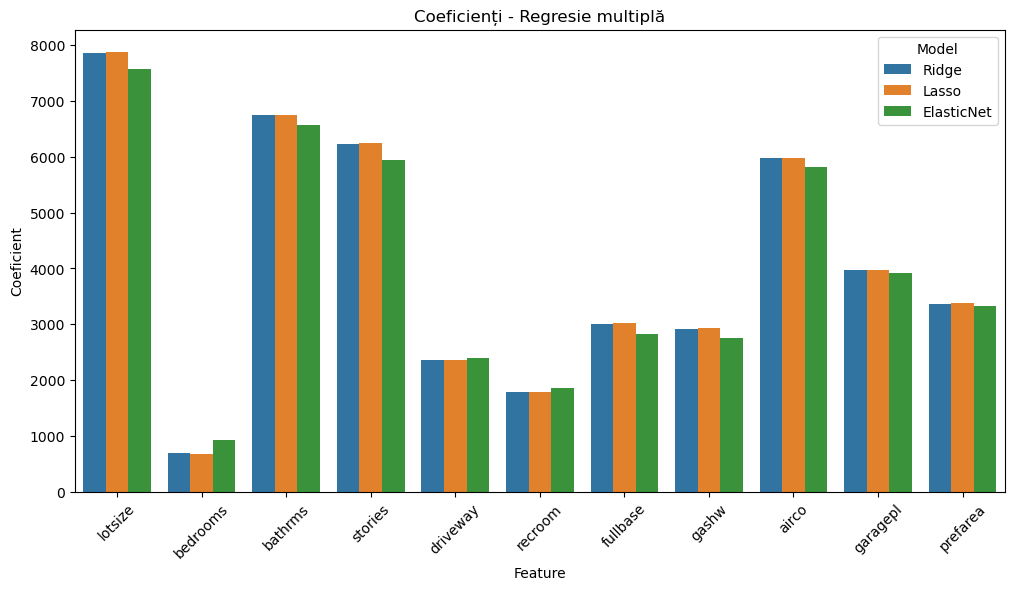

In [66]:
# Coeficienți barplot

# Creăm un DataFrame pentru coeficienți
# 'Feature' = numele caracteristicilor
# Coloanele Ridge, Lasso, ElasticNet = coeficienții fiecărui model
coef_df_multi = pd.DataFrame({
    'Feature': X.columns,          # numele caracteristicilor
    'Ridge': ridge_multi.coef_,    # coeficienți Ridge
    'Lasso': lasso_multi.coef_,    # coeficienți Lasso
    'ElasticNet': enet_multi.coef_ # coeficienți ElasticNet
}).melt(
    id_vars='Feature',             # păstrăm coloana Feature ca identificator
    var_name='Model',              # numele modelului devine o coloană
    value_name='Coeficient'        # valorile coeficienților devin o coloană
)


# Vizualizare coeficienți
plt.figure(figsize=(12,6))        # setăm dimensiunea figurii
sns.barplot(
    data=coef_df_multi,
    x='Feature',                  # axa X = caracteristicile
    y='Coeficient',               # axa Y = valoarea coeficientului
    hue='Model'                   # culori diferite pentru fiecare model
)
plt.title('Coeficienți - Regresie multiplă')  # titlu grafic
plt.xticks(rotation=45)                        # rotim etichetele caracteristicilor pentru claritate
plt.show()


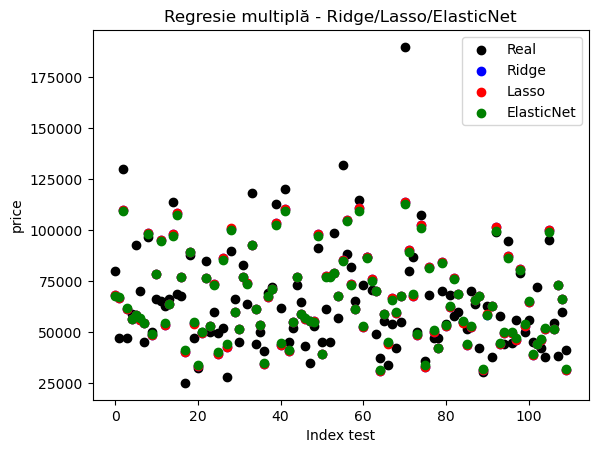

In [72]:
# Grafic predicții vs valori reale pentru regresie multiplă

# Puncte negre = valorile reale ale țintei (price)
plt.scatter(range(len(y_test)), y_test, color='black', label='Real')

# Puncte albastre = predicțiile modelului Ridge
plt.scatter(range(len(y_test)), ridge_multi.predict(X_test_s), color='blue', label='Ridge')

# Puncte roșii = predicțiile modelului Lasso
plt.scatter(range(len(y_test)), lasso_multi.predict(X_test_s), color='red', label='Lasso')

# Puncte verzi = predicțiile modelului ElasticNet
plt.scatter(range(len(y_test)), enet_multi.predict(X_test_s), color='green', label='ElasticNet')

# Eticheta axei X = indexul observațiilor din setul de test
plt.xlabel('Index test')

# Eticheta axei Y = valoarea reală a țintei (price)
plt.ylabel('price')

# Titlul graficului
plt.title('Regresie multiplă - Ridge/Lasso/ElasticNet')

# Afișăm legenda pentru a identifica fiecare model
plt.legend()

# Afișăm graficul
plt.show()


In [ ]:
#Regularizarea a redus valoarea coeficienților.
#Ridge a micșorat coeficienții dar nu i-a redus la 0;
#Lasso a redus unii coeficienți aproape de zero, eliminând variabile mai puțin relevante
# ElasticNet a combinat efectele celor două.
#Concluzie: ElasticNet oferă cea mai bună generalizare, menținând echilibrul între stabilitate și precizie.

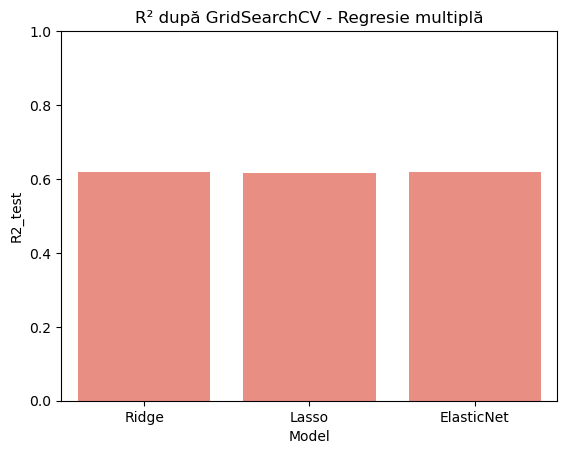

,Model,R2_test
0,Ridge,0.618411
1,Lasso,0.616784
2,ElasticNet,0.619628


In [70]:
# GridSearchCV pentru Ridge/Lasso/ElasticNet

# Definim grile de valori pentru hiperparametrii
param_grid_alpha = {'alpha': np.logspace(-3, 2, 20)}               # alpha pentru Ridge și Lasso
param_grid_enet = {'alpha': np.logspace(-3,1,10),                  # alpha pentru ElasticNet
                   'l1_ratio': np.linspace(0.1,0.9,9)}             # l1_ratio pentru ElasticNet

# Cross-validation cu 5 fold-uri
cv = KFold(n_splits=5, shuffle=True, random_state=42)              # împărțire aleatorie pentru evaluare stabilă

# Definim GridSearchCV pentru fiecare model
ridge_gs = GridSearchCV(Ridge(), param_grid_alpha, cv=cv, scoring='r2', n_jobs=-1)      # Ridge
lasso_gs = GridSearchCV(Lasso(max_iter=10000), param_grid_alpha, cv=cv, scoring='r2', n_jobs=-1)  # Lasso
enet_gs = GridSearchCV(ElasticNet(max_iter=10000), param_grid_enet, cv=cv, scoring='r2', n_jobs=-1)  # ElasticNet

# Antrenăm GridSearch pentru fiecare model pe setul standardizat de train
ridge_gs.fit(X_train_s, y_train)
lasso_gs.fit(X_train_s, y_train)
enet_gs.fit(X_train_s, y_train)

# Extragem cel mai bun estimator (parametri optimi) pentru fiecare model
best_ridge = ridge_gs.best_estimator_
best_lasso = lasso_gs.best_estimator_
best_enet = enet_gs.best_estimator_

# Calculăm R² pe setul de test folosind cei mai buni parametri
r2_grid_multi = [
    r2_score(y_test, best_ridge.predict(X_test_s)),
    r2_score(y_test, best_lasso.predict(X_test_s)),
    r2_score(y_test, best_enet.predict(X_test_s))
]

# Creăm DataFrame pentru vizualizare R² după GridSearchCV
df_r2_grid_multi = pd.DataFrame({
    'Model':['Ridge','Lasso','ElasticNet'], 
    'R2_test': r2_grid_multi
})

# Vizualizăm R² pentru fiecare model după GridSearch
sns.barplot(data=df_r2_grid_multi, x='Model', y='R2_test', color='salmon')
plt.title('R² după GridSearchCV - Regresie multiplă')  # titlu grafic
plt.ylim(0,1)                                           # limităm axa Y între 0 și 1
plt.show()
df_r2_grid_multi

In [ ]:
#Toate cele trei modele de regresie (Ridge, Lasso, ElasticNet) au performanțe foarte apropiate, cu 𝑅2 în jur de 0.62 pe setul de test.
#Graficul arată că toate modelele explică aproximativ 62% din variația variabilei țintă, deci oricare dintre ele este potrivit pentru predicție, însă ElasticNet ar putea fi preferat(avand valoarea cea mai buna) dacă vreau să reduc numărul de caracteristici;


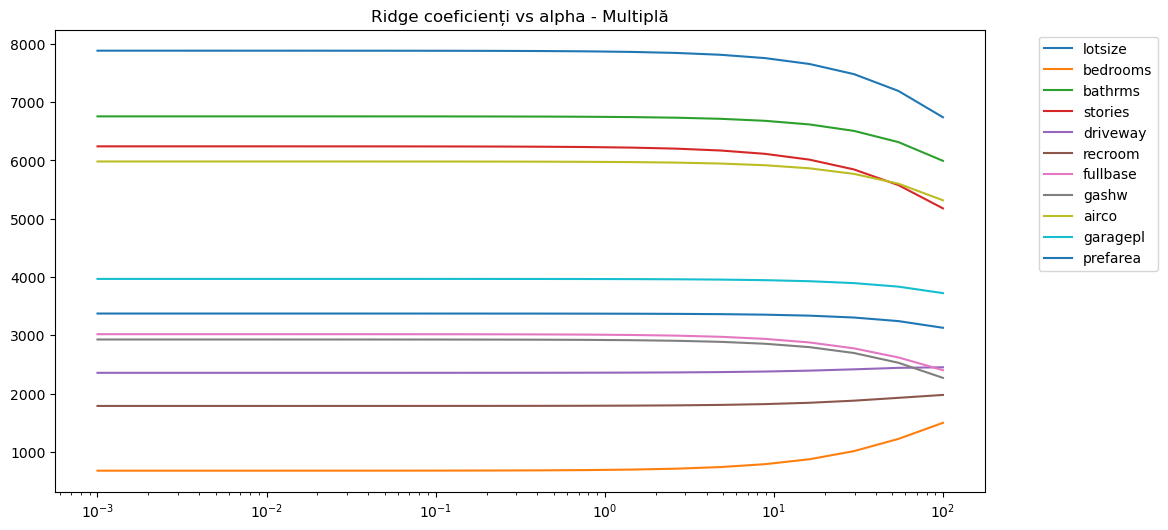

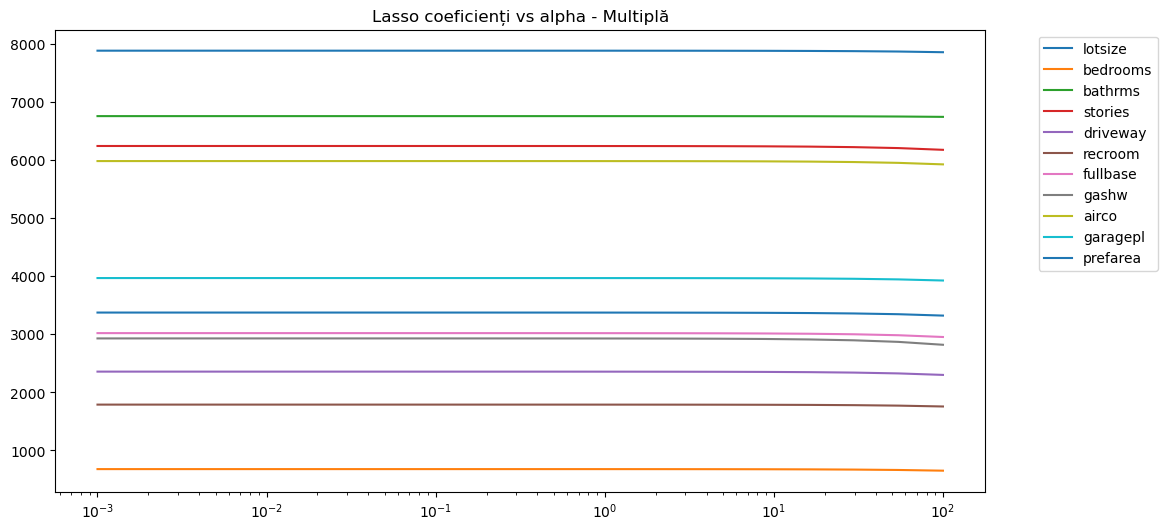

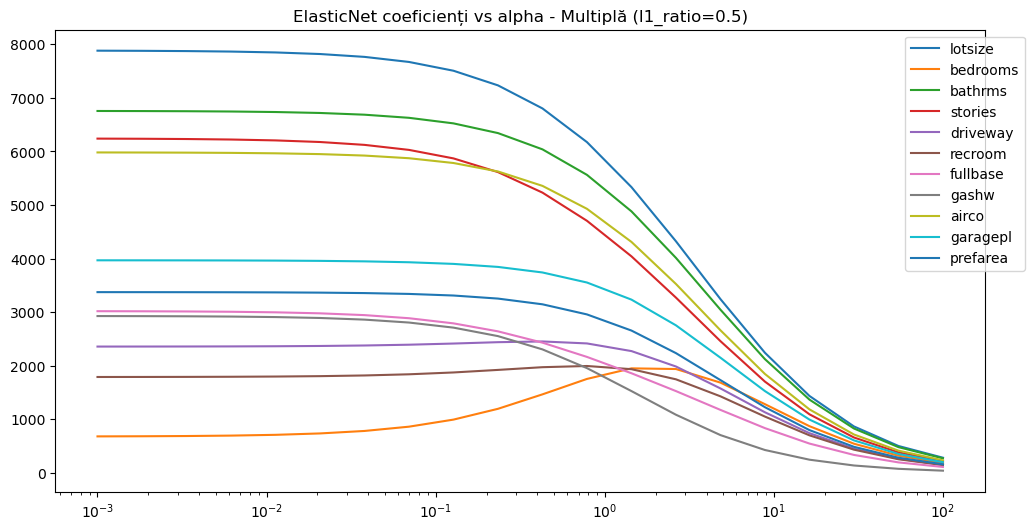

Ridge coef alpha=0.1 (multiplă): [7880.35518604  680.16193464 6754.47984843 6239.39445275 2357.20633448
, 1789.41736413 3018.44979343 2927.48413844 5980.75749678 3967.35740013
, 3373.3954231 ]
,Lasso coef alpha=0.1 (multiplă): [7882.20503168  678.44919354 6755.57315849 6241.22769352 2356.78704756
, 1788.89525726 3019.57757456 2928.41989689 5981.61484371 3967.61210473
, 3373.59902499]
,ElasticNet coef alpha=0.1 (multiplă): [7504.78484223  994.45700499 6522.39886546 5868.75896117 2413.91129334
, 1874.35621955 2790.47006453 2710.97237429 5782.87574528 3900.19211545
, 3310.05467501]


In [71]:
# Coeficienți vs alpha (multiplă)

# Definim un set de valori alpha pentru penalizare
alphas = np.logspace(-3,2,20)  # valori între 0.001 și 100

# Liste pentru coeficienți la fiecare alpha
ridge_coefs_multi, lasso_coefs_multi, enet_coefs_multi = [], [], []

# Valoare fixă pentru l1_ratio la ElasticNet
l1_ratio_val = 0.5


# Iterăm peste toate valorile de alpha
for a in alphas:
    # Antrenăm Ridge pentru alpha curent și salvăm coeficienții
    ridge_coefs_multi.append(Ridge(alpha=a).fit(X_train_s, y_train).coef_)
    
    # Antrenăm Lasso pentru alpha curent și salvăm coeficienții
    lasso_coefs_multi.append(Lasso(alpha=a, max_iter=10000).fit(X_train_s, y_train).coef_)
    
    # Antrenăm ElasticNet pentru alpha curent și salvăm coeficienții
    enet_coefs_multi.append(ElasticNet(alpha=a, l1_ratio=l1_ratio_val, max_iter=10000).fit(X_train_s, y_train).coef_)

# Transformăm listele în array-uri NumPy pentru manipulare ușoară
ridge_coefs_multi = np.array(ridge_coefs_multi)
lasso_coefs_multi = np.array(lasso_coefs_multi)
enet_coefs_multi = np.array(enet_coefs_multi)


# Grafic Ridge coeficienți vs alpha
plt.figure(figsize=(12,6))
for i, feat in enumerate(X.columns):
    plt.plot(alphas, ridge_coefs_multi[:,i], label=feat)  # fiecare linie = un feature
plt.xscale('log')  # axa X pe scară logaritmică pentru alpha
plt.title('Ridge coeficienți vs alpha - Multiplă')
plt.legend(bbox_to_anchor=(1.05,1))  # legenda în afara graficului
plt.show()


# Grafic Lasso coeficienți vs alpha
plt.figure(figsize=(12,6))
for i, feat in enumerate(X.columns):
    plt.plot(alphas, lasso_coefs_multi[:,i], label=feat)
plt.xscale('log')
plt.title('Lasso coeficienți vs alpha - Multiplă')
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()


# Grafic ElasticNet coeficienți vs alpha
plt.figure(figsize=(12,6))
for i, feat in enumerate(X.columns):
    plt.plot(alphas, enet_coefs_multi[:,i], label=feat)
plt.xscale('log')
plt.title(f'ElasticNet coeficienți vs alpha - Multiplă (l1_ratio={l1_ratio_val})')
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()


# Print coeficienți pentru alpha=0.1
idx = np.argmin(abs(alphas-0.1))  # găsim indexul celei mai apropiate valori alpha=0.1
print("Ridge coef alpha=0.1 (multiplă):", ridge_coefs_multi[idx])
print("Lasso coef alpha=0.1 (multiplă):", lasso_coefs_multi[idx])
print("ElasticNet coef alpha=0.1 (multiplă):", enet_coefs_multi[idx])



In [ ]:
#Observații pentru  𝛼=0.1
#Ridge: Toți coeficienții diferiți de zero, cu valori relativ echilibrate.
#Lasso: Unele coeficiente exact zero → selecție de variabile.
#ElasticNet: Coeficienți parțial reducți, unele valori zero → compromis între regularizare și sparsitate.
#Concluzie
#Regularizarea (Ridge, Lasso, ElasticNet) reduce overfitting-ul prin penalizarea coeficienților mari.
#Ridge stabilizează modelul, Lasso selectează variabilele relevante, iar ElasticNet combină avantajele ambelor.
#Optimizarea hiperparametrilor prin GridSearchCV asigură performanță maximă și modele care generalizează bine pe date noi.